# biocal interactive tutorial

# 1 Getting started

## 1.1 Installing the biocal package

To run this toturial you must have installed the `biocal` package in your python environment. If you have not done so already, you can follow the instructions at the [github repository](https://www.github.com/bryanlougheed/biocal) on how to install the package to your python environment using the Linux terminal, Mac terminal, Windows powershell or equivalent.

## 1.2 Importing the `biocal()` function 

After installation, we can import the `biocal()` function into our python session, as well as `biocal_plot()`. We will also import `matplotlib` so that we can plot some things, and `numpy` in case we need it.

If you need to consult the documention for the function then you can always type `?biocal` into the python command line.

In [109]:
import numpy as np
from matplotlib import pyplot as plt
from biocal import biocal, biocal_plot

# 2 Calibrate a <sup>14</sup>C determination using priors for SAR an BD

Below, we can use the `biocal()` function to calibrate a fictional foraminifera sample with a <sup>14</sup>C determination 17500 +/- 100 14C <sup>14</sup>C yrs (`Adet` and `sigdet`). 

We will use the calibration curve (`calcurve`) Marine20 and apply a constant reservoir effect prior (`res`) of 100 +/- 50 <sup>14</sup>C yrs. In this case, as we are using Marine20, reservoir effect is relative to the  marine curve, often reffered to as ΔR.

We will apply a sediment accumulation rate prior (`sar`) of 10 cm/kyr and a bioturbation depth prior (`bd`) of 10 cm. 

We can also make an assumption about how much of the foraminifera population in the sample consists of broken shells which were not picked and included in the sample. According to bioturbation theory, the broken shells represent the oldest fraction of the population that has been subjected to more residency time in the bioturbated layer and is more likely to be broken. (This, however, might not always the case, as due to changing environmental conditions through time, foraminifera might have build less robust (thinner) shell material, so the broken fragments might not always represent the oldest fraction). We will assume that 10% of the foraminifera population is broken and thus not picked for the sample, so we will set `brok` to 0.1. 

We assume constant temporal abundance of the foraminifera species, so we set `abu` to empty. 

Calibrated age units (`yeartype`) will be specified in `Cal BP` (as opposed to `BCE/CE`).

After calibrating with `biocal()` we can use `biocal_plot()` to visualise the calibration results.

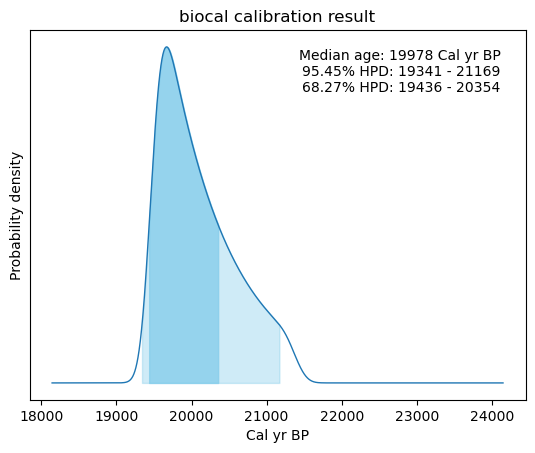

In [110]:
# Lab 14C determination
Adet = 17500 # 14C age of lab determination in 14C yrs
sigdet = 100 # lab measurement error
# Calibration curve and output units
calcurve = 'Marine20' # calibration curve we will use
yeartype = 'Cal BP' # calibrated years output unit
# Bayesian priors
sar = 12 # assumed Sediment Accumulation Rate
bd = 10 # assumed Bioturbation Depth
brok = 0.1 # fraction (between 0 and 1) of the foram population assume to be broken shells
abu = [] # temporal changes in foram abundance, leave blank to assume constant abundance
res = [100, 50] # constant reservoir effect. res effect +/- uncertainty

# Now call the biocal function with the above inputs
p95_4, p68_2, calprob, medage = biocal(Adet, sigdet, calcurve, yeartype, sar, bd, brok, abu, res)

# plot output from biocal calibration
biocal_plot(p95_4, p68_2, calprob, medage, yeartype)

# 3 Include a temporal abundance prior

## 3.1 Prepare the temporal abundace prior

In the previous example we calibrated using the assumption of a constant foraminiferal abundance. In the following example, we can also see how `biocal()` can take temporal species into account. Let's assume for a moment that the species <i>S. Fiction</i> has been <sup>14</sup>C-analysed and has a temporal abundance that follows a sine wave. Obviously a sine wave is highly unrealistic, and in reality we'd need to source real species abundance reconstructions from the literature or suitable species abundance data from a palaeoclimate model. We just use a sine wave here to demonstrate the principle of calibrating with temporal abundance data for the purposes of this tutorial.




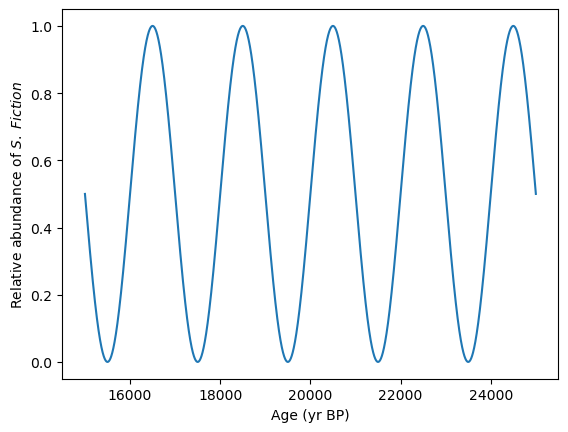

In [111]:
# make a sine wave for a theoretical, fictional abundance
age = np.arange(15000, 25001, 1)
wavelength = 2000
abundance = np.sin((2 * np.pi * age) / wavelength) # this will produce values between -1 and 1
# make the abundance values between 0 and 1, suitable for biocal. 
# abundance is relative to the species itself (i.e. not to other species)
abundance = (abundance +1) / 2 

plt.plot(age,abundance)
plt.xlabel('Age (yr BP)')
plt.ylabel(r'Relative abundance of $\mathit{S.\ Fiction}$')

plt.show()

## 3.2 Calibrate with the temporal abundance prior

Now we can repeat the calibration process that we had done before, this time using the temporal abundance prior. `biocal()` requires abundance to be inputted in as `abu`, a two column array of `[age, abundance]`, which has been done in the sample below. We can see that, in this case, the species abundance function results in a somewhat multi-model age distribution.




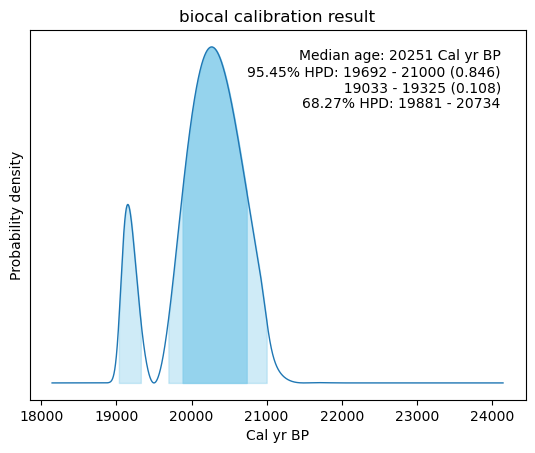

In [112]:
# Lab 14C determination
Adet = 17500 # 14C age of lab determination in 14C yrs
sigdet = 100 # lab measurement error
# Calibration curve and output units
calcurve = 'Marine20' # calibration curve we will use
yeartype = 'Cal BP' # calibrated years output unit
# Bayesian priors
sar = 12 # assumed Sediment Accumulation Rate
bd = 10 # assumed Bioturbation Depth
brok = 0.1 # fraction (between 0 and 1) of the foram population assume to be broken shells
# temporal changes in foram abundance, col 1 = age in yr BP, col 2 = abundance between 0 and 1
abu = np.column_stack((age, abundance))
res = [100, 50] # constant reservoir effect. res effect +/- uncertainty

# Now call the function with the above inputs
p95_4, p68_2, calprob, medage = biocal(Adet, sigdet, calcurve, yeartype, sar, bd, brok, abu, res)

# plot output from function
biocal_plot(p95_4, p68_2, calprob, medage, yeartype)

# 4 Include a temporal <sup>14</sup>C reservoir effect prior

In the previous examples we calibrated using the assumption of a constant <sup>14</sup>C reservoir effect. Below we include millennial scale changes in reservoir effect. `biocal()` will linearly interpolate between the inputted ages. Also here it would be possible to use a realistic reservoir effect sourced from palaeoclimate reconsructions or models.


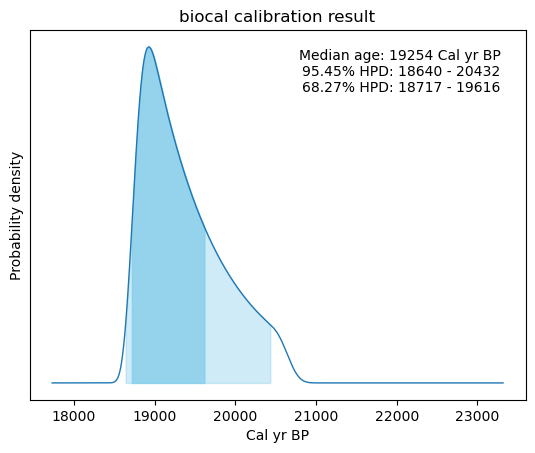

In [113]:
# Lab 14C determination
Adet = 17500 # 14C age of lab determination in 14C yrs
sigdet = 100 # lab measurement error
# Calibration curve and output units
calcurve = 'Marine20' # calibration curve we will use
yeartype = 'Cal BP' # calibrated years output unit
# Bayesian priors
sar = 12 # assumed Sediment Accumulation Rate
bd = 10 # assumed Bioturbation Depth
brok = 0.1 # fraction (between 0 and 1) of the foram population assume to be broken shells
# temporal changes in foram abundance, col 1 = age in yr BP, col 2 = abundance between 0 and 1
abu = [];
# temporal reservoir effect array. 
# column 1 = yr BP, column 2= reservoir effect in 14C yr, column 3 = 14C yr uncertainty 
res = ([
    [17000, 400, 40],
    [18000, 500, 40],
    [19000, 600, 40],
    [20000, 800, 80],
    [21000, 900, 70],
    [22000, 600, 50]
])

# Now call the function with the above inputs
p95_4, p68_2, calprob, medage = biocal(Adet, sigdet, calcurve, yeartype, sar, bd, brok, abu, res)

# plot output from function 
biocal_plot(p95_4, p68_2, calprob, medage, yeartype)